In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
import difflib  # For fuzzy matching on inputs (e.g., misspellings)
warnings.filterwarnings('ignore')

In [2]:
# Simulating a dataset with 1000 samples for future disease risk prediction.
np.random.seed(42)  # For reproducibility
n_samples = 1000

data = {
    'Age': np.random.randint(18, 80, n_samples),
    'Gender': np.random.choice(['M', 'F'], n_samples),
    'Breakfast': np.random.choice(['junk', 'normal', 'vegetables', 'fruits'], n_samples),
    'Lunch': np.random.choice(['junk', 'normal', 'vegetables', 'fruits'], n_samples),
    'Dinner': np.random.choice(['junk', 'normal', 'vegetables', 'fruits'], n_samples),
    'Snacks': np.random.choice(['junk', 'normal', 'vegetables', 'fruits'], n_samples)
}

df = pd.DataFrame(data)

# Simulate Disease_Risk (1 = high risk of future disease, e.g., diabetes/obesity/heart issues)
df['Disease_Risk'] = 0
risk_factors = (
    (df['Age'] > 40).astype(int) +
    (df['Breakfast'] == 'junk').astype(int) +
    (df['Lunch'] == 'junk').astype(int) +
    (df['Dinner'] == 'junk').astype(int) +
    (df['Snacks'] == 'junk').astype(int) +
    (df['Gender'] == 'M').astype(int) * 0.5  # Slight gender bias simulation
)
df['Disease_Risk'] = (risk_factors > 2).astype(int)  # Threshold for high risk

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDisease Risk Distribution:")
print(df['Disease_Risk'].value_counts())

Dataset shape: (1000, 7)

First 5 rows:
   Age Gender   Breakfast       Lunch      Dinner      Snacks  Disease_Risk
0   56      M  vegetables  vegetables  vegetables  vegetables             0
1   69      M        junk  vegetables      fruits      normal             1
2   46      F  vegetables      fruits      fruits      normal             0
3   32      M        junk        junk  vegetables      normal             1
4   60      M  vegetables        junk      fruits      fruits             1

Disease Risk Distribution:
Disease_Risk
0    594
1    406
Name: count, dtype: int64


In [3]:
X = df.drop('Disease_Risk', axis=1)
y = df['Disease_Risk']

# Identify categorical columns
categorical_features = ['Gender', 'Breakfast', 'Lunch', 'Dinner', 'Snacks']
numerical_features = ['Age']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Data preparation complete.
Training set size: 800 samples
Test set size: 200 samples


In [4]:
# Preprocessing: One-Hot Encode categoricals, leave numerical as-is
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Pipeline with Random Forest Classifier
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       119
           1       1.00      0.91      0.95        81

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



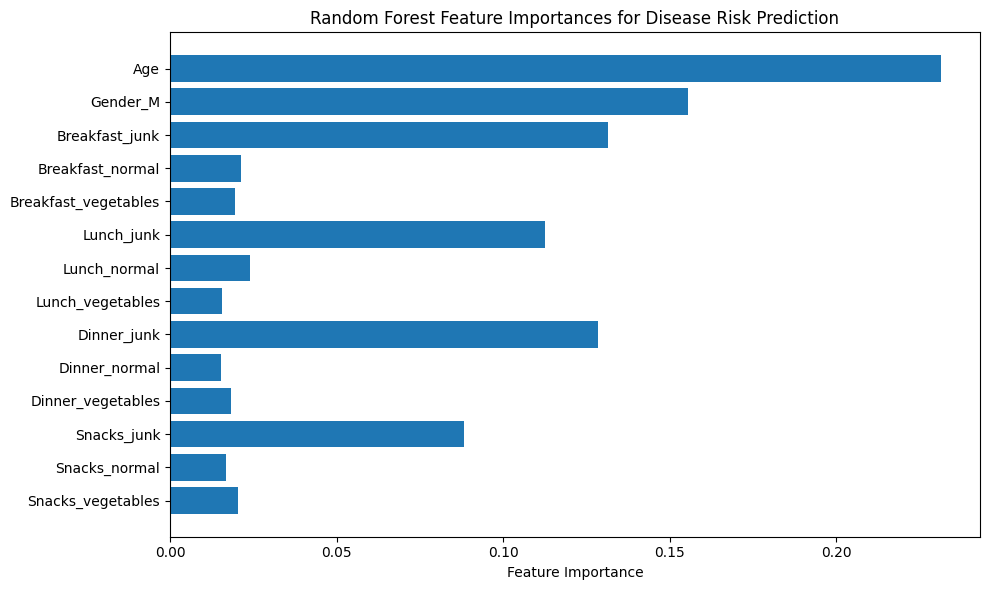

In [5]:
# Get feature names after preprocessing
feature_names = numerical_features + list(model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))
importances = model.named_steps['classifier'].feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances for Disease Risk Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
def predict_disease_risk(age, gender, breakfast, lunch, dinner, snacks, condition='none'):
    """
    Enhanced prediction with condition handling and fuzzy input correction.
    
    Args:
    - age: int (e.g., 45)
    - gender: str ('M' or 'F')
    - breakfast, lunch, dinner, snacks: str ('junk', 'normal', 'vegetables', 'fruits') - fuzzy matched
    - condition: str ('none', 'cancer', 'pregnant', 'diabetes', 'heart_disease', or other)
    
    Returns: Prediction/advice and details.
    """
    valid_foods = ['junk', 'normal', 'vegetables', 'fruits']
    
    # Fuzzy correction function for food types
    def correct_food_type(input_str):
        input_str = input_str.lower().strip()
        if input_str in valid_foods:
            return input_str
        # Find closest match
        matches = difflib.get_close_matches(input_str, valid_foods, n=1, cutoff=0.6)
        if matches:
            corrected = matches[0]
            print(f"Auto-corrected '{input_str}' to '{corrected}' (common misspelling).")
            return corrected
        return None  # No match
    
    # Correct food types
    breakfast = correct_food_type(breakfast)
    lunch = correct_food_type(lunch)
    dinner = correct_food_type(dinner)
    snacks = correct_food_type(snacks)
    
    # Validate after correction
    if gender.upper() not in ['M', 'F']:
        print(f"Error: Invalid gender '{gender}'. Must be 'M' or 'F'.")
        return None, None
    if not any(meal == input_str for meal in [breakfast, lunch, dinner, snacks] for input_str in valid_foods):
        print(f"Error: Invalid meal type(s). Valid options: {', '.join(valid_foods)}.")
        return None, None
    
    try:
        age = int(age)
    except ValueError:
        print("Error: Age must be an integer (18-80).")
        return None, None
    
    # Special cases: Provide daily food habit recommendations (educational only - consult a doctor)
    if condition.lower() != 'none':
        print(f"\nSpecial Advice for {condition.title()} Condition:")
        print("Daily Food Habit Recommendations (Balanced 3 meals + 2 snacks; ~2000-2500 calories):")
        if 'cancer' in condition.lower():
            print("- Breakfast: Oatmeal with fruits/berries (antioxidants). Avoid junk.")
            print("- Lunch: Grilled chicken salad with veggies (leafy greens for vitamins).")
            print("- Dinner: Baked fish with quinoa and broccoli (lean protein, fiber).")
            print("- Snacks: Nuts or yogurt (healthy fats). Hydrate well; limit processed foods.")
            print("- Tip: Focus on anti-inflammatory foods; aim for 5+ servings of fruits/veggies daily.")
        elif 'pregnant' in condition.lower() or 'pregnancy' in condition.lower():
            print("- Breakfast: Whole-grain toast with avocado and eggs (folate, healthy fats).")
            print("- Lunch: Lentil soup with spinach and yogurt (iron, calcium). Avoid raw fish/meat.")
            print("- Dinner: Salmon with sweet potatoes and greens (omega-3, vitamins).")
            print("- Snacks: Fresh fruits or cheese (nutrient-dense). Eat small, frequent meals.")
            print("- Tip: Include dairy for calcium; consult prenatal guidelines; no alcohol/caffeine excess.")
        elif 'diabetes' in condition.lower():
            print("- Breakfast: Veggie omelet with whole grains (low-GI, protein).")
            print("- Lunch: Chickpea salad with cucumber/tomato (fiber-rich, balanced carbs).")
            print("- Dinner: Grilled tofu with brown rice and beans (steady blood sugar).")
            print("- Snacks: Apple with almonds (low sugar, healthy fats). Monitor portions.")
            print("- Tip: Choose low-GI foods; track carbs; pair with exercise.")
        elif 'heart' in condition.lower():
            print("- Breakfast: Fruit smoothie with oats (fiber for cholesterol).")
            print("- Lunch: Turkey wrap with veggies (low sodium, lean meat).")
            print("- Dinner: Steamed veggies with lentils (potassium-rich, low fat).")
            print("- Snacks: Carrot sticks or berries (heart-healthy antioxidants).")
            print("- Tip: Reduce salt/junk; include omega-3 sources like fish; 30min daily walk.")
        else:
            print("- General Advice: Follow a balanced diet with more vegetables/fruits, less junk.")
            print("- Breakfast: Fruits/oats. Lunch: Veggies/protein. Dinner: Normal/veggies. Snacks: Fruits.")
            print("- Tip: Hydrate; consult a nutritionist for personalized plan.")
        print("Note: This is general guidance. Always consult a healthcare professional.")
        return 'advice_provided', None
    
    # Default: ML Prediction for future risk (condition='none')
    input_data = pd.DataFrame({
        'Age': [age],
        'Gender': [gender],
        'Breakfast': [breakfast],
        'Lunch': [lunch],
        'Dinner': [dinner],
        'Snacks': [snacks]
    })
    
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]  # Probability of high risk
    
    risk_level = 'High Risk' if prediction == 1 else 'Low Risk'
    print(f"\nFuture Disease Risk Prediction (No Current Condition):")
    print(f"Based on inputs (Age: {age}, Gender: {gender}, Meals: {breakfast}/{lunch}/{dinner}/{snacks}):")
    print(f"Predicted Future Disease Risk: {risk_level}")
    print(f"Risk Probability: {probability:.2%}")
    print("Tip: Improve diet with more vegetables/fruits to reduce risk.")
    return prediction, probability

print("Enhanced prediction function defined successfully!")

Enhanced prediction function defined successfully!


In [8]:
# Step-by-Step Interactive Starter with (1)/(2) Choice and Re-Prompts
print("Welcome to the Diet and Disease Risk Advisor!")
print("This tool helps with future risk prediction or personalized diet advice for conditions.")
print("Note: This is educational only - consult a doctor for medical advice.\n")

# Step 1: Initial (1)/(2) question
print("Do you (1) want to know if your diet may cause disease in future? or (2) already are you faced with disease and you want diet for the disease?")
while True:
    choice = input("Enter your choice (1 or 2): ").strip().lower()
    if choice in ['1', 'one']:
        break
    elif choice in ['2', 'two']:
        break
    else:
        print("Invalid choice. Please enter '1' or '2'.")

if choice in ['1', 'one']:
    # Option 1: Future risk prediction with re-prompts
    print("\nSelected Option 1: Future Risk Prediction.")
    print("Providing your diet details for analysis...")
    
    # Re-prompt for age
    while True:
        age_input = input("Enter your age (18-80): ").strip()
        try:
            age = int(age_input)
            if 18 <= age <= 80:
                break
            else:
                print("Age must be between 18-80. Try again.")
        except ValueError:
            print("Age must be a number. Try again.")
    
    # Re-prompt for gender
    while True:
        gender = input("Enter your gender (M/F): ").strip().upper()
        if gender in ['M', 'F']:
            break
        print("Gender must be 'M' or 'F'. Try again.")
    
    # Re-prompt for meals (let function handle fuzzy correction)
    valid_foods = ['junk', 'normal', 'vegetables', 'fruits']
    breakfast = input(f"Breakfast food type ({', '.join(valid_foods)}): ").strip().lower()
    lunch = input(f"Lunch food type ({', '.join(valid_foods)}): ").strip().lower()
    dinner = input(f"Dinner food type ({', '.join(valid_foods)}): ").strip().lower()
    snacks = input(f"Snacks food type ({', '.join(valid_foods)}): ").strip().lower()
    
    # Run ML prediction (condition='none') - function will correct and validate
    result = predict_disease_risk(age, gender, breakfast, lunch, dinner, snacks, 'none')
    if result[0] is None:
        print("Invalid inputs after corrections. Please re-run the cell.")
elif choice in ['2', 'two']:
    # Option 2: Disease/condition diet advice with re-prompt
    print("\nSelected Option 2: Personalized Diet for Disease/Condition.")
    while True:
        disease_type = input("What is your disease/condition? (e.g., cancer, pregnancy, diabetes, heart_disease, other): ").strip().lower()
        if disease_type:  # Any non-empty input is accepted for flexibility
            break
        print("Please enter a disease/condition name. Try again.")
    
    # Run advice (dummy values for age/gender/meals - ignored in advice mode)
    result = predict_disease_risk(30, 'F', 'normal', 'normal', 'normal', 'normal', disease_type)
    print("Advice generated successfully.")

print("\nInteraction complete. Re-run this cell for another session.")

Welcome to the Diet and Disease Risk Advisor!
This tool helps with future risk prediction or personalized diet advice for conditions.
Note: This is educational only - consult a doctor for medical advice.

Do you (1) want to know if your diet may cause disease in future? or (2) already are you faced with disease and you want diet for the disease?


Enter your choice (1 or 2):  1



Selected Option 1: Future Risk Prediction.
Providing your diet details for analysis...


Enter your age (18-80):  20
Enter your gender (M/F):  M
Breakfast food type (junk, normal, vegetables, fruits):  normal
Lunch food type (junk, normal, vegetables, fruits):  normal
Dinner food type (junk, normal, vegetables, fruits):  normal
Snacks food type (junk, normal, vegetables, fruits):  normal



Future Disease Risk Prediction (No Current Condition):
Based on inputs (Age: 20, Gender: M, Meals: normal/normal/normal/normal):
Predicted Future Disease Risk: Low Risk
Risk Probability: 0.00%
Tip: Improve diet with more vegetables/fruits to reduce risk.

Interaction complete. Re-run this cell for another session.
